In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utility import *
from tools import *
from maps import *
from scipy.stats import linregress
from scipy.ndimage import maximum_filter, label
from scipy.spatial.distance import pdist, squareform

In [2]:
# Load the data of cell coordinates, spike latency and Rli background of the slice under control condition (no Quinine applied).
index = []

with open('C:/Users/Kevin/Desktop/26-02-17/02_01_04_location.dat', 'r') as f:
    for element in f:
        clean = element.strip()[1:-1]
        numbers = clean.split()
        index.append(np.array(numbers, dtype=int))

index = np.array(index)

latency = []

with open('C:/Users/Kevin/Desktop/26-02-17/02_01_04_latency.dat', 'r') as f:
    for element in f:
        clean = element.strip()[1:-1]
        numbers = clean.split()
        latency.append(np.array(numbers, dtype=float))
        
latency = np.array(latency)

rli = []

with open('C:/Users/Kevin/Desktop/26-02-17/02_01_04_rli.dat', 'r') as f:
    for element in f:
        clean = element.strip()[1:-1]
        numbers = clean.split()
        rli.append(np.array(numbers, dtype=float))
        
rli = np.array(rli)

In [3]:
# Load the data of cell coordinates, spike latency and Rli background of the slice under control condition (Quinine applied).
index_Q = []

with open('C:/Users/Kevin/Desktop/26-02-17/02_01_05_location.dat', 'r') as f:
    for element in f:
        clean = element.strip()[1:-1]
        numbers = clean.split()
        index_Q.append(np.array(numbers, dtype=int))

index_Q = np.array(index_Q)

latency_Q = []

with open('C:/Users/Kevin/Desktop/26-02-17/02_01_05_latency.dat', 'r') as f:
    for element in f:
        clean = element.strip()[1:-1]
        numbers = clean.split()
        latency_Q.append(np.array(numbers, dtype=float))
        
latency_Q = np.array(latency_Q)

rli_Q = []

with open('C:/Users/Kevin/Desktop/26-02-17/02_01_05_rli.dat', 'r') as f:
    for element in f:
        clean = element.strip()[1:-1]
        numbers = clean.split()
        rli_Q.append(np.array(numbers, dtype=float))
        
rli_Q = np.array(rli_Q)

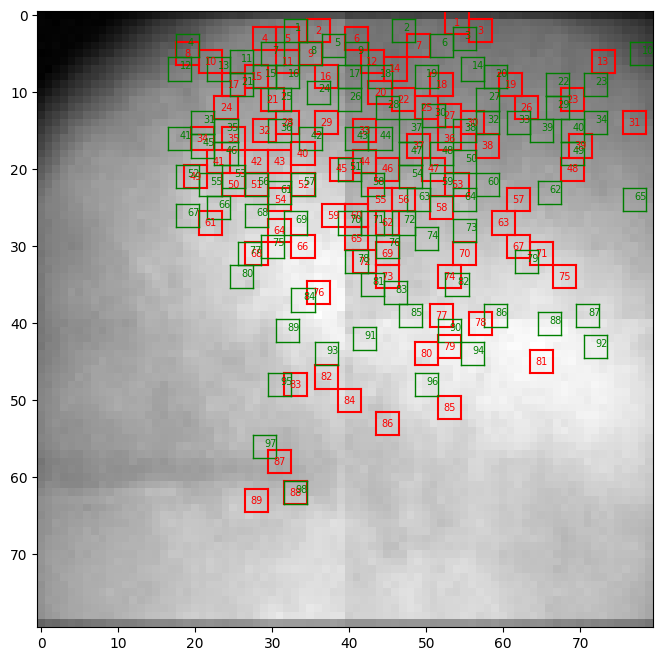

In [4]:
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(rli, cmap='gray')

for i, coor in enumerate(index):
    
    r = coor[1]
    c = coor[0]
    
    top = r - 1.5
    bottom = r + 1.5
    left = c - 1.5
    right = c + 1.5

    ax.plot([top, top], [left, right], color='red', linewidth=1.5)
    ax.plot([bottom, bottom], [left, right], color='red', linewidth=1.5)
    ax.plot([top, bottom], [left, left], color='red', linewidth=1.5)
    ax.plot([top, bottom], [right, right], color='red', linewidth=1.5)
    ax.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='red')

for i, coor in enumerate(index_Q):
    
    r = coor[1]
    c = coor[0]
    
    top = r - 1.5
    bottom = r + 1.5
    left = c - 1.5
    right = c + 1.5

    ax.plot([top, top], [left, right], color='green', linewidth=1)
    ax.plot([bottom, bottom], [left, right], color='green', linewidth=1)
    ax.plot([top, bottom], [left, left], color='green', linewidth=1)
    ax.plot([top, bottom], [right, right], color='green', linewidth=1)
    ax.annotate(str(i+1), xy=(r, c), fontsize=7, color='green')
    
plt.show()

Neuron without Quinine:
Neuron 88 and Neuron 57 are correlated with a positive slope, and the P-Value is: 0.000717 , distance is: 286.81004166521086 um.
Neuron with Quinine:
Neuron 98 and Neuron 2 are correlated with a positive slope, and the P-Value is: 0.013233 , distance is: 369.6701232179847 um.


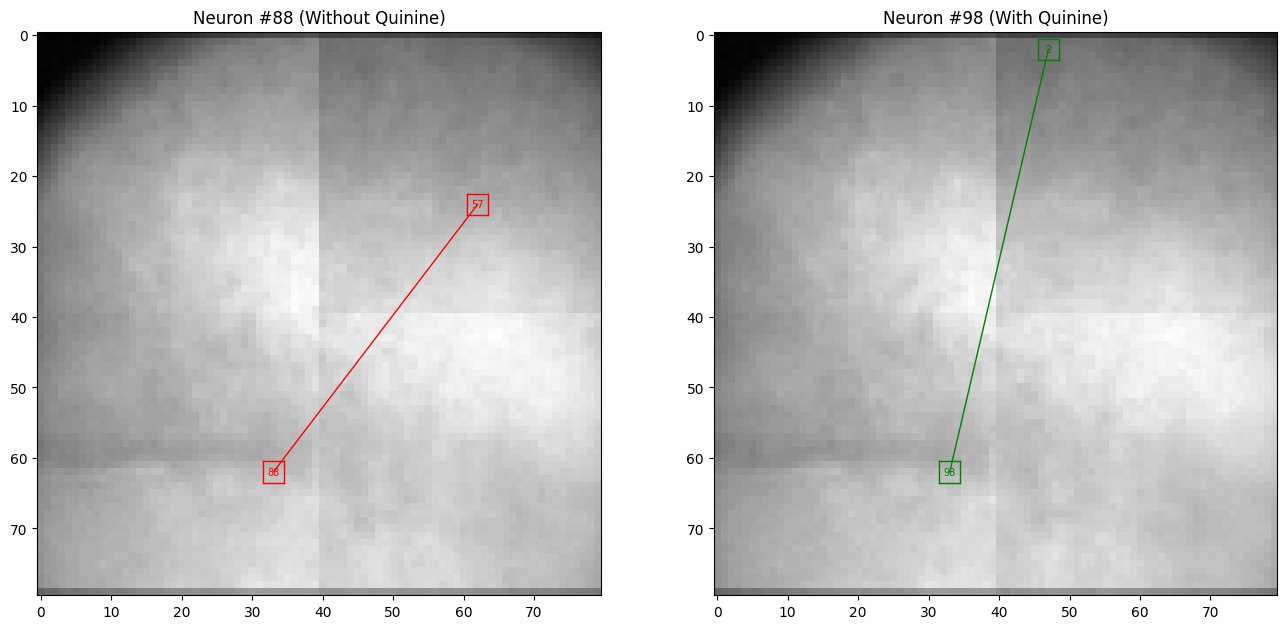

In [5]:
# Slice with and without Quinine.
neuro_label = 88
neuro_label_Q = 98

plt.subplots(1, 2, figsize=(16, 8))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)

ax1.imshow(rli, cmap='gray')
top = index[neuro_label-1][1] - 1.5
bottom = index[neuro_label-1][1] + 1.5
left = index[neuro_label-1][0] - 1.5
right = index[neuro_label-1][0] + 1.5

ax1.plot([top, top], [left, right], color='red', linewidth=1)
ax1.plot([bottom, bottom], [left, right], color='red', linewidth=1)
ax1.plot([top, bottom], [left, left], color='red', linewidth=1)
ax1.plot([top, bottom], [right, right], color='red', linewidth=1)
ax1.annotate(str(neuro_label), xy=(index[neuro_label-1][1], index[neuro_label-1][0]), ha='center', va='center', fontsize=7, color='red')
ax1.set_title('Neuron #{} (Without Quinine)'.format(neuro_label))

ax2.imshow(rli_Q, cmap='gray')
top = index_Q[neuro_label_Q-1][1] - 1.5
bottom = index_Q[neuro_label_Q-1][1] + 1.5
left = index_Q[neuro_label_Q-1][0] - 1.5
right = index_Q[neuro_label_Q-1][0] + 1.5

ax2.plot([top, top], [left, right], color='green', linewidth=1)
ax2.plot([bottom, bottom], [left, right], color='green', linewidth=1)
ax2.plot([top, bottom], [left, left], color='green', linewidth=1)
ax2.plot([top, bottom], [right, right], color='green', linewidth=1)
ax2.annotate(str(neuro_label_Q), xy=(index_Q[neuro_label_Q-1][1], index_Q[neuro_label_Q-1][0]), ha='center', va='center', fontsize=7, color='green')
ax2.set_title('Neuron #{} (With Quinine)'.format(neuro_label_Q))

Pvalue = []
Distance = []
print('Neuron without Quinine:')
for i in range(len(index)):

    if i == neuro_label - 1:
        continue
    else:
        dist = np.sqrt((index[i][0] - index[neuro_label-1][0])**2 + (index[i][1] - index[neuro_label-1][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency[i], latency[neuro_label-1])

        if pValue <=0.05 and Slope > 0:
            print('Neuron', neuro_label, 'and Neuron', i+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')
            Pvalue.append(pValue)
            Distance.append(dist)
            loc_1 = index[i]
            loc_2 = index[neuro_label-1]

            ax1.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)

            top = loc_1[1] - 1.5
            bottom = loc_1[1] + 1.5
            left = loc_1[0] - 1.5
            right = loc_1[0] + 1.5

            ax1.plot([top, top], [left, right], color='red', linewidth=1)
            ax1.plot([bottom, bottom], [left, right], color='red', linewidth=1)
            ax1.plot([top, bottom], [left, left], color='red', linewidth=1)
            ax1.plot([top, bottom], [right, right], color='red', linewidth=1)
            ax1.annotate(str(i+1), xy=(loc_1[1], loc_1[0]), ha='center', va='center', fontsize=7, color='red')
            
Pvalue = np.array(Pvalue)
Distance = np.array(Distance)

Pvalue_Q = []
Distance_Q = []
print('Neuron with Quinine:')
for i in range(len(index_Q)):

    if i == neuro_label_Q - 1:
        continue
    else:
        dist = np.sqrt((index_Q[i][0] - index_Q[neuro_label_Q-1][0])**2 + (index_Q[i][1] - index_Q[neuro_label_Q-1][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency_Q[i], latency_Q[neuro_label_Q-1])

        if pValue <=0.05 and Slope > 0:
            print('Neuron', neuro_label_Q, 'and Neuron', i+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')
            Pvalue_Q.append(pValue)
            Distance_Q.append(dist)
            loc_1 = index_Q[i]
            loc_2 = index_Q[neuro_label_Q-1]

            ax2.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='green', linewidth=1)

            top = loc_1[1] - 1.5
            bottom = loc_1[1] + 1.5
            left = loc_1[0] - 1.5
            right = loc_1[0] + 1.5

            ax2.plot([top, top], [left, right], color='green', linewidth=1)
            ax2.plot([bottom, bottom], [left, right], color='green', linewidth=1)
            ax2.plot([top, bottom], [left, left], color='green', linewidth=1)
            ax2.plot([top, bottom], [right, right], color='green', linewidth=1)
            ax2.annotate(str(i+1), xy=(loc_1[1], loc_1[0]), ha='center', va='center', fontsize=7, color='green')
            
Pvalue_Q = np.array(Pvalue_Q)
Distance_Q = np.array(Distance_Q)

plt.show()

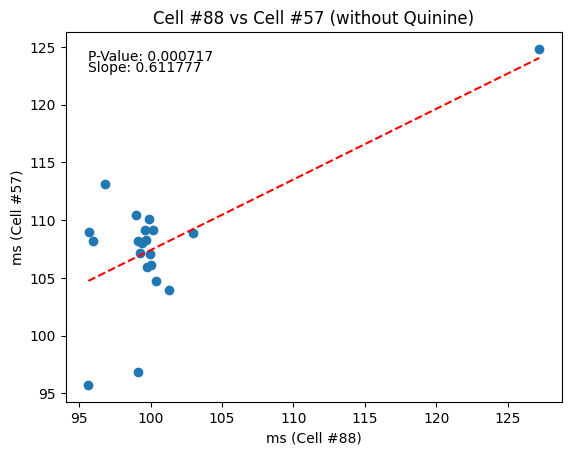

In [6]:
# Latency correlation between two identified cells under no Quinine condition.
neuro_label_1 = 88
neuro_label_2 = 57

slope, D, _, P, _ = linregress(latency[neuro_label_1-1], latency[neuro_label_2-1])
array = np.linspace(np.min(latency[neuro_label_1-1]), np.max(latency[neuro_label_1-1]), 1000)

plt.scatter(latency[neuro_label_1-1], latency[neuro_label_2-1])
plt.plot(array, array*slope + D, linestyle='--', color='red')
plt.xlabel('ms (Cell #{})'.format(neuro_label_1))
plt.ylabel('ms (Cell #{})'.format(neuro_label_2))
plt.title('Cell #{} vs Cell #{} (without Quinine)'.format(neuro_label_1, neuro_label_2))
plt.annotate('P-Value: {}'.format(round(P, 6)), [np.min(latency[neuro_label_1-1]), np.max(latency[neuro_label_2-1])-1])
plt.annotate('Slope: {}'.format(round(slope, 6)), [np.min(latency[neuro_label_1-1]), np.max(latency[neuro_label_2-1])-2])
plt.show()

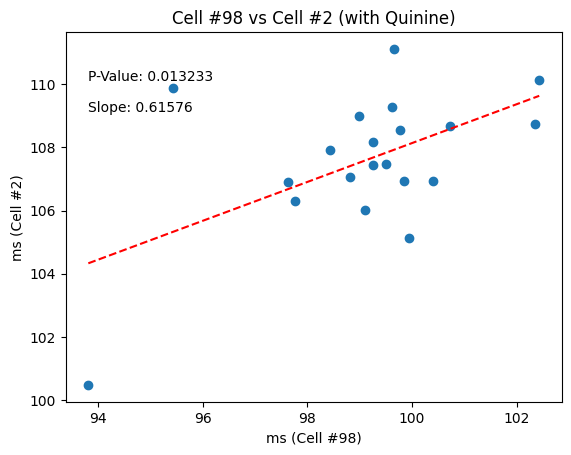

In [7]:
# Latency correlation between two identified cells under Quinine condition.
neuro_label_Q_1 = 98
neuro_label_Q_2 = 2

slope, D, _, P, _ = linregress(latency_Q[neuro_label_Q_1-1], latency_Q[neuro_label_Q_2-1])
array = np.linspace(np.min(latency_Q[neuro_label_Q_1-1]), np.max(latency_Q[neuro_label_Q_1-1]), 1000)

plt.scatter(latency_Q[neuro_label_Q_1-1], latency_Q[neuro_label_Q_2-1])
plt.plot(array, array*slope + D, linestyle='--', color='red')
plt.xlabel('ms (Cell #{})'.format(neuro_label_Q_1))
plt.ylabel('ms (Cell #{})'.format(neuro_label_Q_2))
plt.title('Cell #{} vs Cell #{} (with Quinine)'.format(neuro_label_Q_1, neuro_label_Q_2))
plt.annotate('P-Value: {}'.format(round(P, 6)), [np.min(latency_Q[neuro_label_Q_1-1]), np.max(latency_Q[neuro_label_Q_2-1])-1])
plt.annotate('Slope: {}'.format(round(slope, 6)), [np.min(latency_Q[neuro_label_Q_1-1]), np.max(latency_Q[neuro_label_Q_2-1])-2])
plt.show()

In [8]:
num = len(index)
trial = latency.shape[1]
count = 0
PValue = []
Distance = []

for i in range(num-1):
    for j in range(i+1, num):
        
        dist = np.sqrt((index[i][0] - index[j][0])**2 + (index[i][1] - index[j][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency[i], latency[j])
        if pValue <=0.05 and Slope > 0:
            count = count + 1
            PValue.append(pValue)
            Distance.append(dist)
            print('Neuron', i+1, 'and Neuron', j+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')

print(count, 'pairs are correlated.')
print('Totally', int(num*(num-1)/2), 'pairs.')
PValue = np.array(PValue)
Distance = np.array(Distance)

Neuron 1 and Neuron 15 are correlated with a positive slope, and the P-Value is: 0.035126 , distance is: 161.55494421403512 um.
Neuron 1 and Neuron 62 are correlated with a positive slope, and the P-Value is: 0.048748 , distance is: 165.08179790637126 um.
Neuron 1 and Neuron 70 are correlated with a positive slope, and the P-Value is: 0.022729 , distance is: 180.0999722376436 um.
Neuron 2 and Neuron 54 are correlated with a positive slope, and the P-Value is: 0.001897 , distance is: 135.36617007214173 um.
Neuron 2 and Neuron 86 are correlated with a positive slope, and the P-Value is: 0.028408 , distance is: 310.72817702937726 um.
Neuron 3 and Neuron 4 are correlated with a positive slope, and the P-Value is: 0.013506 , distance is: 168.1071087134628 um.
Neuron 3 and Neuron 55 are correlated with a positive slope, and the P-Value is: 0.012905 , distance is: 153.32318807016765 um.
Neuron 4 and Neuron 16 are correlated with a positive slope, and the P-Value is: 0.006047 , distance is: 56

In [9]:
num = len(index_Q)
trial = latency_Q.shape[1]
count = 0
PValue_Q = []
Distance_Q = []

for i in range(num-1):
    for j in range(i+1, num):
        
        dist = np.sqrt((index_Q[i][0] - index_Q[j][0])**2 + (index_Q[i][1] - index_Q[j][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency_Q[i], latency_Q[j])
        if pValue <=0.05 and Slope > 0:
            count = count + 1
            PValue_Q.append(pValue)
            Distance_Q.append(dist)
            print('Neuron', i+1, 'and Neuron', j+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')

print(count, 'pairs are correlated.')
print('Totally', int(num*(num-1)/2), 'pairs.')
PValue_Q = np.array(PValue_Q)
Distance_Q = np.array(Distance_Q)

Neuron 1 and Neuron 11 are correlated with a positive slope, and the P-Value is: 0.003134 , distance is: 48.373546489791295 um.
Neuron 1 and Neuron 27 are correlated with a positive slope, and the P-Value is: 0.030254 , distance is: 159.42396306703708 um.
Neuron 1 and Neuron 29 are correlated with a positive slope, and the P-Value is: 0.016316 , distance is: 212.6405417600322 um.
Neuron 1 and Neuron 39 are correlated with a positive slope, and the P-Value is: 0.035849 , distance is: 207.23899247004653 um.
Neuron 1 and Neuron 52 are correlated with a positive slope, and the P-Value is: 0.006967 , distance is: 141.60508465447137 um.
Neuron 1 and Neuron 53 are correlated with a positive slope, and the P-Value is: 0.042248 , distance is: 123.69316876852983 um.
Neuron 1 and Neuron 69 are correlated with a positive slope, and the P-Value is: 0.002388 , distance is: 150.0 um.
Neuron 1 and Neuron 71 are correlated with a positive slope, and the P-Value is: 0.001214 , distance is: 161.554944214